In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount into drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'
# Verify the contents of the current folder
#!ls

/content/drive/MyDrive/hateful_meme


**Validation**

In [ ]:
# validation
df = pd.read_csv("report/validation_vilbert.csv")
df.columns = ['id', 'proba', 'predicted_label']

In [ ]:
#validation
import json
labels = []
file = open("data/dev_seen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)
file = open("data/dev_unseen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)

In [ ]:
df_truth = pd.DataFrame(labels)
df_final = pd.merge(df, df_truth, how='left', on='id')
def getType(row):
  if row['predicted_label'] == row['label'] and row['label'] == 1:
    return "TP"
  elif row['predicted_label'] == row['label'] and row['label'] == 0:
    return "TN"
  elif row['predicted_label'] == 1 and row['label'] == 0:
    return "FP"
  elif row['predicted_label'] == 0 and row['label'] == 1:
    return "FN"
df_final['type'] = df_final.apply(lambda row: getType(row), axis=1)
df_final = df_final.drop_duplicates()
df_final.head()

,id,proba,predicted_label,img,label,text,type
0,8291,0.551373,1,img/08291.png,1,white people is this a shooting range,TP
2,46971,0.196330,0,img/46971.png,1,bravery at its finest,FN
4,3745,0.206501,0,img/03745.png,1,your order comes to $37.50 and your white priv...,FN
6,83745,0.664322,1,img/83745.png,1,it is time.. to send these parasites back to t...,TP
8,80243,0.331835,0,img/80243.png,1,mississippi wind chime,FN


              precision    recall  f1-score   support

 Non-Hateful       0.49      0.68      0.57       253
     Hateful       0.46      0.27      0.34       247

    accuracy                           0.48       500
   macro avg       0.47      0.48      0.46       500
weighted avg       0.47      0.48      0.46       500



Text(0.5, 1.0, 'Confusion Matrix for Vilbert')

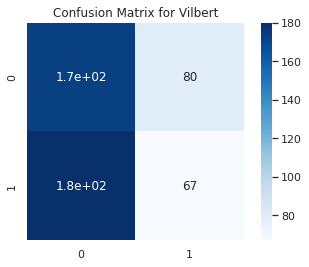

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, precision_recall_curve, plot_precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

print(classification_report(df_final['label'], df_final['predicted_label'], target_names=['Non-Hateful', 'Hateful']))
conf = confusion_matrix(df_final['label'], df_final['predicted_label'])
sns.heatmap(conf, annot=True, square=True, cmap="Blues")
plt.title("Confusion Matrix for Vilbert")

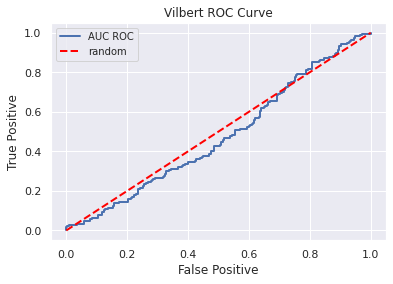

In [ ]:
fpr, tpr, thresholds1 = roc_curve(df_final['label'], df_final['proba'])
plt.figure(1)
plt.title("Vilbert ROC Curve")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.plot(fpr,tpr, linewidth=2, label="AUC ROC")
plt.plot([0,1],[0,1], linestyle="dashed", color="red", linewidth=2, label="random")
plt.legend(fontsize=10, loc="best")
plt.savefig('roc_vilbert.png')
plt.show()


In [ ]:
roc_auc = np.trapz(tpr, fpr)
print("ROC AUC: ", roc_auc)


ROC AUC:  0.4749963994815254


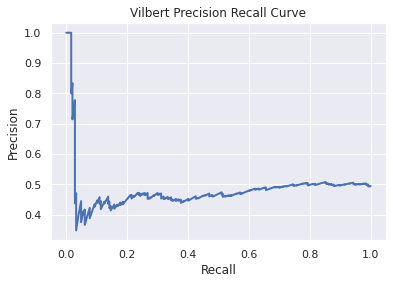

In [ ]:
plt.figure(2)
plt.title("Vilbert Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
precision, recall, thresholds2 = precision_recall_curve(df_final['label'], df_final['proba'])
plt.plot(recall, precision, linewidth=2)
plt.show()

In [ ]:
df_final.groupby("type")['id'].count()

type
FN    180
FP     80
TN    173
TP     67
Name: id, dtype: int64

In [ ]:
top_tp = df_final[df_final['type']=='TP'].sort_values('proba', ascending=False).head()
top_tn = df_final[df_final['type']=='TN'].sort_values('proba', ascending=True).head()
top_fp = df_final[df_final['type']=='FP'].sort_values('proba', ascending=False).head(10)
top_fn = df_final[df_final['type']=='FN'].sort_values('proba', ascending=True).head(10)

In [ ]:
top_fp

,id,proba,predicted_label,img,label,text,type
804,16749,0.809539,1,img/16749.png,0,broken dishwasher,FP
197,37420,0.806162,1,img/37420.png,0,like lebanon terrorism can destroy a beautiful...,FP
744,93041,0.798399,1,img/93041.png,0,"""who's gonna make the sandwiches? what do we d...",FP
217,19523,0.780056,1,img/19523.png,0,they see them rollin.... they hating..,FP
454,68257,0.772746,1,img/68257.png,0,everyone is afraid of dark,FP
740,30586,0.765557,1,img/30586.png,0,just can't get rid of the stain. this is why i...,FP
211,76092,0.753292,1,img/76092.png,0,everybody is afraid of gangs,FP
840,61085,0.746011,1,img/61085.png,0,upper downer,FP
299,34209,0.741002,1,img/34209.png,0,how about a nice 12 yr old? bartender: him: bo...,FP
250,79615,0.733739,1,img/79615.png,0,what women think men want what men really want,FP


In [ ]:
top_tn

,id,proba,predicted_label,img,label,text,type
319,91602,0.087019,0,img/91602.png,0,upper downer,TN
476,63987,0.105742,0,img/63987.png,0,the migrant caravan arrives!,TN
506,54819,0.109542,0,img/54819.png,0,beauty shot of girlfriends focusing on differe...,TN
376,53609,0.111095,0,img/53609.png,0,when your friend insists on paying for dinner ...,TN
240,16420,0.121531,0,img/16420.png,0,abnormal vs normal,TN


In [ ]:
top_fp

,id,proba,predicted_label,img,label,text,type
804,16749,0.809539,1,img/16749.png,0,broken dishwasher,FP
197,37420,0.806162,1,img/37420.png,0,like lebanon terrorism can destroy a beautiful...,FP
744,93041,0.798399,1,img/93041.png,0,"""who's gonna make the sandwiches? what do we d...",FP
217,19523,0.780056,1,img/19523.png,0,they see them rollin.... they hating..,FP
454,68257,0.772746,1,img/68257.png,0,everyone is afraid of dark,FP
740,30586,0.765557,1,img/30586.png,0,just can't get rid of the stain. this is why i...,FP
211,76092,0.753292,1,img/76092.png,0,everybody is afraid of gangs,FP
840,61085,0.746011,1,img/61085.png,0,upper downer,FP
299,34209,0.741002,1,img/34209.png,0,how about a nice 12 yr old? bartender: him: bo...,FP
250,79615,0.733739,1,img/79615.png,0,what women think men want what men really want,FP


In [ ]:
top_fn

,id,proba,predicted_label,img,label,text,type
800,18059,0.070445,0,img/18059.png,1,"they are like sperm you get millions, but only...",FN
115,18945,0.105162,0,img/18945.png,1,when you decide to go full gas,FN
164,83946,0.123970,0,img/83946.png,1,when a white kid shoots up the school the same...,FN
303,46920,0.127829,0,img/46920.png,1,we want sharia law !! well.... go home,FN
129,29437,0.139882,0,img/29437.png,1,what can happen if you eat wheaties for 38 years,FN
868,29054,0.142174,0,img/29054.png,1,broken dishwasher,FN
620,45702,0.144742,0,img/45702.png,1,"if she's still making noises, you didn't hit h...",FN
268,96472,0.145013,0,img/96472.png,1,white power!,FN
64,91586,0.145674,0,img/91586.png,1,left the kitchen too many times,FN
574,10285,0.150733,0,img/10285.png,1,you are what you eat meanwhile in africa,FN


In [ ]:
import cv2
def plot_top_memes(df_top, incorrect=False):
  root = '/root/.cache/torch/mmf/data/datasets/hateful_memes/defaults/images/'
  if incorrect:
    fig, ax = plt.subplots(2, 5, figsize=(35, 20))
  else:
    fig, ax = plt.subplots(1, 5, figsize=(35, 10))
  imgs = df_top['img'].values
  for i, img in enumerate(imgs):
    im_arr = cv2.imread(root + img)
    im_arr = cv2.cvtColor(im_arr, cv2.COLOR_BGR2RGB)
    if incorrect:
      ax[i//5, i%5].imshow(im_arr)
      ax[i//5, i%5].grid(False)
      ax[i//5, i%5].set_yticklabels([])
      ax[i//5, i%5].set_xticklabels([])
    else:
      ax[i].imshow(im_arr)
      ax[i].grid(False)
      ax[i].set_yticklabels([])
      ax[i].set_xticklabels([])

In [ ]:
plot_top_memes(top_tp)

In [ ]:
plot_top_memes(top_fp)

In [ ]:
plot_top_memes(top_tn)

In [ ]:
plot_top_memes(top_fn)

**Test**

In [ ]:
df = pd.read_csv("report/test_vilbert.csv")
df.columns = ['id', 'proba', 'predicted_label']

In [35]:
# NEW WORK
import numpy as np
from PIL import Image
import csv
import json
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt 
import seaborn as sn
from sklearn.metrics import roc_auc_score
%matplotlib inline

In [36]:
# Mount into drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'

/content/drive/MyDrive/hateful_meme


In [38]:
# Ground Truth
valid = pd.read_json("data/dev_seen.jsonl", lines=True)

In [39]:
valid.head()

,id,img,label,text
0,8291,img/08291.png,1,white people is this a shooting range
1,46971,img/46971.png,1,bravery at its finest
2,3745,img/03745.png,1,your order comes to $37.50 and your white priv...
3,83745,img/83745.png,1,it is time.. to send these parasites back to t...
4,80243,img/80243.png,1,mississippi wind chime


In [40]:
# Ground truth labels
actual = {valid['id'][i]:valid['label'][i] for i in range(500)}

In [41]:
valid.set_index("id", inplace=True)

In [42]:
# Helper Functions
'''
Returns True Positives, False Positives, True Negatives, False Negatives, AUROC_score
'''
def Statistics(actual, pred_labels, pred_prob, sorted_dict):
    
    #Correctly Predicted
    True_positives = defaultdict(int)
    True_negatives = defaultdict(int)


    #Benign Meme but predicted hateful
    False_positives = defaultdict(int)

    # Hateful Meme, but predicted Benign
    False_negatives = defaultdict(int)



    for ids in list(actual.keys()):

        if actual[ids] != pred_labels[ids]:

            if pred_prob[ids]>=0.5:
                False_positives[ids] = pred_prob[ids]

            else:
                 False_negatives[ids] = pred_prob[ids]   


        else:
            if pred_prob[ids]>=0.5:
                True_positives[ids] = pred_prob[ids]

            else:
                 True_negatives[ids] = pred_prob[ids]   
            
        
    return sorted_dict(True_positives), sorted_dict(True_negatives), sorted_dict(False_positives),  sorted_dict(False_negatives)
     

    

'''
Get count of True Positives, False Positives, True Negatives, False Negatives
'''
def count(True_positives, True_negatives, False_positives,  False_negatives):
    
    tp = len(True_positives)
    tn = len(True_negatives)
    fp = len(False_positives)
    fn = len(False_negatives)
    total = tp+tn+fp+fn
    
    return tp,tn,fp,fn,total




'''
Plots Confusion Matrix
'''
def plot_confusion_matrix(tn, fp, fn, tp, AUROC_score,total):
    
    
    matrix = np.array(([tn, fp],[fn,tp]))
    percent = (matrix/matrix.sum())*100
    
    accuracy = ((tp+tn)/total)*100
    Precision = (tp/(tp+fp))*100
    Recall = (tp/(tp+fn))*100
    F1_score =  2 * (Precision * Recall) / (Precision + Recall)
    
    
    df_cm = pd.DataFrame(matrix, ['Benign','Hateful'], ['Benign','Hateful'])
    text = np.asarray([['True Negatives', 'False Positives'], ['False Negatives', 'True Positives']])
    label = (np.asarray(["{0}\n\n{1}\n\n{2: .2f}%".format(text,matrix,percent) for text, matrix, percent in zip(text.flatten(), matrix.flatten(), percent.flatten())])).reshape(2,2)
    
    plt.figure(figsize=(10,10))
    sn.set(font_scale=2)
    sn.heatmap(df_cm, annot=label, annot_kws={"size": 20}, cbar_kws={'label':"Memes"}, fmt ='', cmap ='Blues')
    
    plt.title('Confusion Matrix', fontsize=20)
    plt.text(0.1, 2.5, 'Precision: '+str(round(Precision,2)) + '        Recall: '+str(round(Recall,2))+'     F1 Score: '+str(round(F1_score,2))+
            '\n\nAccuracy: '+ str(round(accuracy,2))+'          AUROC:'+ str(round(AUROC_score,2)), fontsize=20)
    plt.show()

    
    
    
'''
Get AUROC score using sklearn.metrics.roc_auc_score
'''
def get_AUROC(actual, pred_labels):
    
    ytrue=[]
    ypred=[]
    for ids in list(actual.keys()):
        ytrue.append(actual[ids])
        ypred.append(pred_labels[ids])

    AUROC_score = roc_auc_score(ytrue, ypred)
    
    return AUROC_score




'''
Return a Dictionary by it's values sorted in descending order
'''
def sorted_dict(unsorted_dictionary):
    sorted_keys = sorted(unsorted_dictionary, key =unsorted_dictionary.__getitem__, reverse=True)

    sorted_values = sorted(unsorted_dictionary.values(),reverse=True)

    sorted_dictionary = {}
    for i in range(len(sorted_keys)):
        sorted_dictionary[sorted_keys[i]] = sorted_values[i]
        
    return sorted_dictionary



'''
Display a Image
'''
def open_image(path, actual, pred_labels, pred_prob):
    label_dict = {0:'Benign', 1:'Hateful'}

    ground_truth = label_dict[actual[image_id]]
    predicted_label = label_dict[pred_labels[image_id]]
    confidence = pred_prob[image_id]
    
    image = Image.open('data/'+path)
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.rcParams["axes.grid"] = False
    plt.text(0,image.size[1]+25, 'Annotated label: '+ ground_truth+ '       Predicted label: '+ predicted_label+ '       Probability: '+ str(round(confidence,4)), fontsize=15)
    plt.imshow(image)

In [43]:
#Analysis of VIlBERT on Validation set

#Predicted labels
%cd '/content/drive/MyDrive/hateful_meme/Baseline/VilBERT' 
predicted = pd.read_csv('hateful_memes_run_val_2021-12-06T22:38:34.csv')

/content/drive/MyDrive/hateful_meme/Baseline/VilBERT


In [44]:
predicted.head()

,id,proba,label
0,8291,8.698669e-05,0
1,46971,3.763566e-07,0
2,3745,3.646267e-06,0
3,83745,1.185264e-06,0
4,80243,9.999671e-01,1


In [45]:
# Predicted Labels
pred_labels = {predicted['id'][i]:predicted['label'][i] for i in range(500)}

In [46]:
# Predicted Probabilities
pred_prob = {predicted['id'][i]:predicted['proba'][i] for i in range(500)}

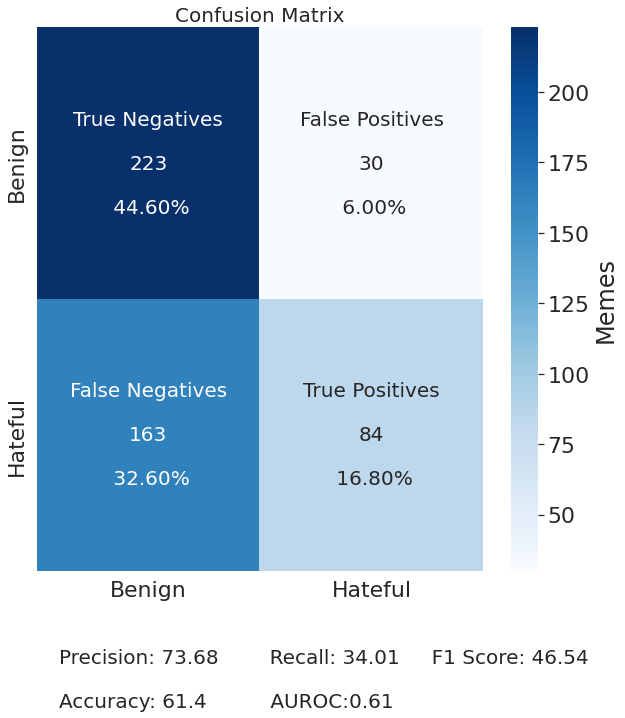

In [47]:
True_positives, True_negatives, False_positives,  False_negatives =  Statistics(actual, pred_labels, pred_prob, sorted_dict)

tp,tn,fp,fn,total = count(True_positives, True_negatives, False_positives,  False_negatives)

AUROC_score = get_AUROC(actual, pred_labels)

plot_confusion_matrix(tn, fp, fn, tp, AUROC_score, total)

/content/drive/MyDrive/hateful_meme


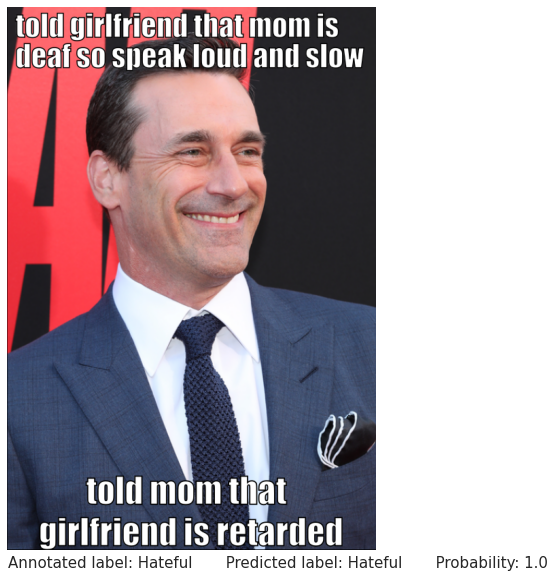

In [48]:
# True Positive with Highest Confidence (Hateful Meme predicted as Hateful)
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'

path = valid.loc[list(True_positives.keys())[0]]['img']
image_id = list(True_positives.keys())[0]
open_image(path, actual, pred_labels, pred_prob)

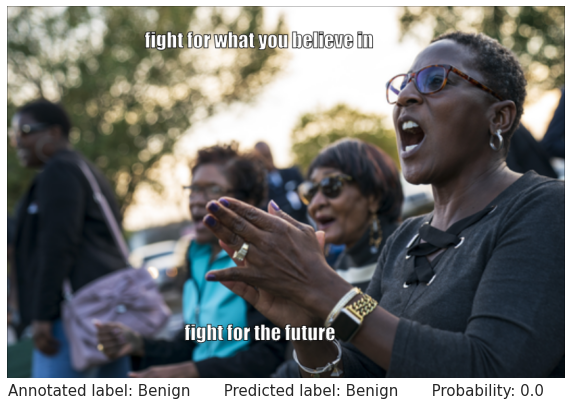

In [49]:
# True Negative with Highest Confidence (Benign meme predicted as Benign)
path = valid.loc[list(True_negatives.keys())[-3]]['img']
image_id = list(True_negatives.keys())[-3]

open_image(path, actual, pred_labels, pred_prob)

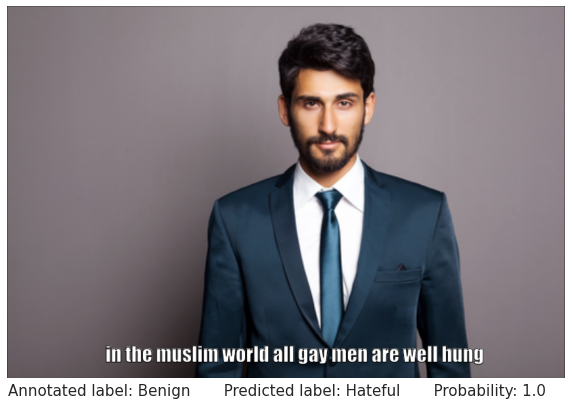

In [50]:
# False Positive with Highest Confidence (Benign meme prediced as Hateful)
path = valid.loc[list(False_positives.keys())[0]]['img']
image_id = list(False_positives.keys())[0]
open_image(path, actual, pred_labels, pred_prob)

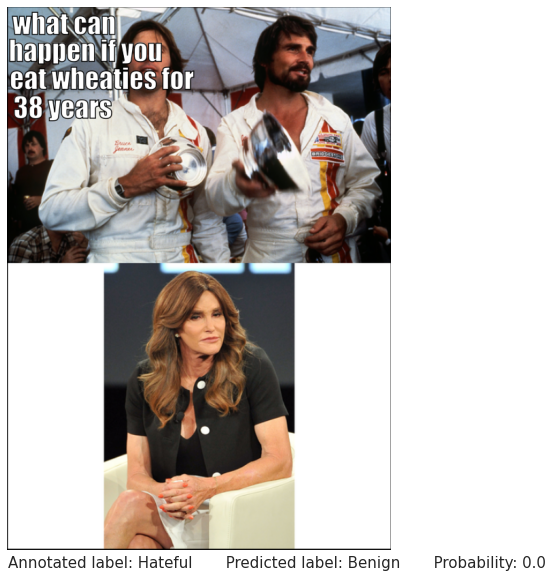

In [51]:
# False Negative with Highest Confidence (Hateful Meme predicted as Benign)
path = valid.loc[list(False_negatives.keys())[-1]]['img']
image_id = list(False_negatives.keys())[-1]
open_image(path, actual, pred_labels, pred_prob)